In [2]:
import cv2
import os
import numpy as np
import pandas as pd
from skimage.measure import label, regionprops
from skimage.feature import graycomatrix, graycoprops
import matplotlib.pyplot as plt

In [3]:
PATH = "../dataset/"

TRAIN_FRESH = os.path.join(PATH, "freshoranges")
TRAIN_ROTTEN = os.path.join(PATH, "rottenoranges")

In [4]:
arquivo = os.listdir(TRAIN_FRESH)[0]

img = cv2.imread(os.path.join(TRAIN_FRESH, arquivo))
img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

In [ ]:
def segmentar_laranja(img_rgb):

    bgr = cv2.cvtColor(img_rgb,cv2.COLOR_RGB2BGR)
    hsv = cv2.cvtColor(bgr,cv2.COLOR_BGR2HSV)

    lower = np.array([5, 50, 50])
    upper = np.array([35, 255, 255])

    mask = cv2.inRange(hsv, lower, upper)

    se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5, 5))

    mask = cv2.morphologyEx(mask,cv2.MORPH_OPEN,se,iterations=2)
    mask = cv2.morphologyEx(mask,cv2.MORPH_CLOSE,se,iterations=3)

    lbl = label(mask > 0)
    props = regionprops(lbl)

    if len(props) == 0:
        return None

    maior = max(props,key=lambda r: r.area).label

    mask_final = (lbl == maior).astype(np.uint8) * 255

    return mask_final

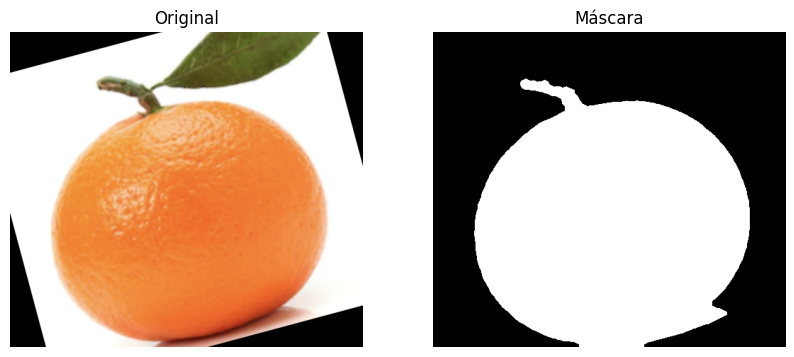

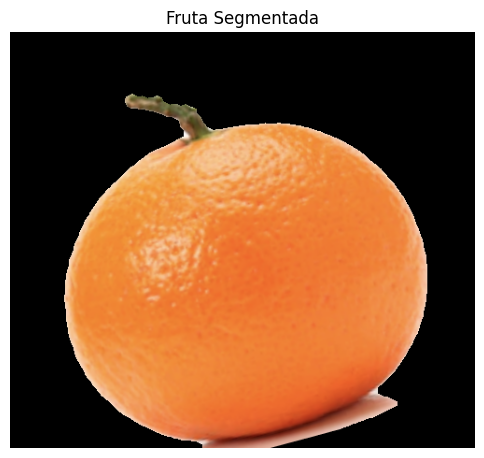

In [6]:
mask = segmentar_laranja(img_rgb)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Máscara")
plt.axis("off")

resultado = cv2.bitwise_and(img_rgb,img_rgb,mask=mask)

plt.figure(figsize=(6,6))
plt.imshow(resultado)
plt.title("Fruta Segmentada")
plt.axis("off")
plt.show()

In [7]:
def features_laranja(img_rgb):

    mask = segmentar_laranja(img_rgb)

    bgr = cv2.cvtColor(img_rgb,cv2.COLOR_RGB2BGR)
    hsv = cv2.cvtColor(bgr,cv2.COLOR_BGR2HSV)
    gray = cv2.cvtColor(bgr,cv2.COLOR_BGR2GRAY)

    pix = mask > 0
    lbl = label(pix)

    regioes = regionprops(lbl,intensity_image=gray)

    if len(regioes) == 0:
        return None

    r = max(regioes,key=lambda x: x.area)

    area = r.area
    perimeter = r.perimeter
    eccentricity = r.eccentricity
    solidity = r.solidity
    extent = r.extent
    circularidade = (4 * np.pi * area) / (perimeter**2)
    contours, _ = cv2.findContours(mask,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    maior = max(contours,key=cv2.contourArea)

    moments = cv2.moments(maior)
    hu = cv2.HuMoments(moments).flatten()
    hu = -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)

    H = hsv[:,:,0][pix]
    S = hsv[:,:,1][pix]
    V = hsv[:,:,2][pix]

    mean_h = H.mean()
    mean_s = S.mean()
    mean_v = V.mean()

    patch_gray = gray[r.slice].copy()
    patch_mask = pix[r.slice]
    valor_neutro = np.median(patch_gray[patch_mask])
    patch_gray[~patch_mask] = valor_neutro
    patch_q = (patch_gray // 32).astype(np.uint8)

    glcm = graycomatrix(
        patch_q,
        distances=[1],
        angles=[0,np.pi/4,np.pi/2,3*np.pi/4],
        levels=8,
        symmetric=True,
        normed=True
    )

    contrast = graycoprops(glcm,'contrast').mean()
    homogeneity = graycoprops(glcm,'homogeneity').mean()
    energy = graycoprops(glcm,'energy').mean()
    correlation = graycoprops(glcm,'correlation').mean()

    return {
        "area": area,
        "perimeter": perimeter,
        "eccentricity": eccentricity,
        "solidity": solidity,
        "extent": extent,
        "circularidade": circularidade,
        "hu1": hu[0],
        "hu2": hu[1],
        "hu3": hu[2],
        "hu4": hu[3],
        "hu5": hu[4],
        "hu6": hu[5],
        "hu7": hu[6],
        "mean_h": mean_h,
        "mean_s": mean_s,
        "mean_v": mean_v,
        "contrast": contrast,
        "homogeneity": homogeneity,
        "energy": energy,
        "correlation": correlation
    }

In [8]:
import pandas as pd

laranjas = []
for l in os.listdir(TRAIN_FRESH):
    laranjas.append(os.path.join(TRAIN_FRESH, l))

for l in os.listdir(TRAIN_ROTTEN):
    laranjas.append(os.path.join(TRAIN_ROTTEN, l))


X = []
y = []
for l in laranjas:

    img = cv2.imread(l)
    img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    retorno = features_laranja(img_rgb)
    retorno["src"] = l 
    X.append(retorno)
    if "rotten" in l:
        y.append("rotten")
    else:
        y.append("fresh")

df_X = pd.DataFrame(X)
df_y = pd.DataFrame(y)

print(df_X.head())
print(df_y.head())

df_X.to_csv("../X.csv", index=False)
df_y.to_csv("../y.csv", index=False)


       area    perimeter  eccentricity  solidity    extent  circularidade  \
0  109211.0  1453.751442      0.386522  0.937755  0.740760       0.649376   
1   31181.0   669.026479      0.432868  0.989433  0.781479       0.875414   
2   34376.0   702.724963      0.372186  0.990406  0.772408       0.874771   
3   30033.0   661.511760      0.199076  0.986143  0.747090       0.862449   
4   95565.0  1206.354473      0.390325  0.987068  0.746019       0.825199   

        hu1       hu2       hu3       hu4  ...       hu6       hu7     mean_h  \
0  0.792131  3.751658  5.111399  6.356599  ... -8.401653  9.996736  12.308559   
1  0.795444  3.558046  5.769221  8.133881  ...  9.788081 -9.999997  15.435329   
2  0.796751  3.848324  5.826903  8.220531  ...  9.933423  9.999998  15.236299   
3  0.797622  4.981488  5.161614  8.195082  ... -9.922200 -9.999999  15.868012   
4  0.794691  3.752818  4.370570  6.695395  ...  8.843622 -9.997755  15.699848   

       mean_s      mean_v  contrast  homogeneity  